In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
url = r"C:\Users\vedba\Documents\DSBDAL_prac\BostonHousing.csv"
df=pd.read_csv(url)
df.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [5]:
df.rename(columns={'medv': 'PRICE'}, inplace=True)

<Axes: >

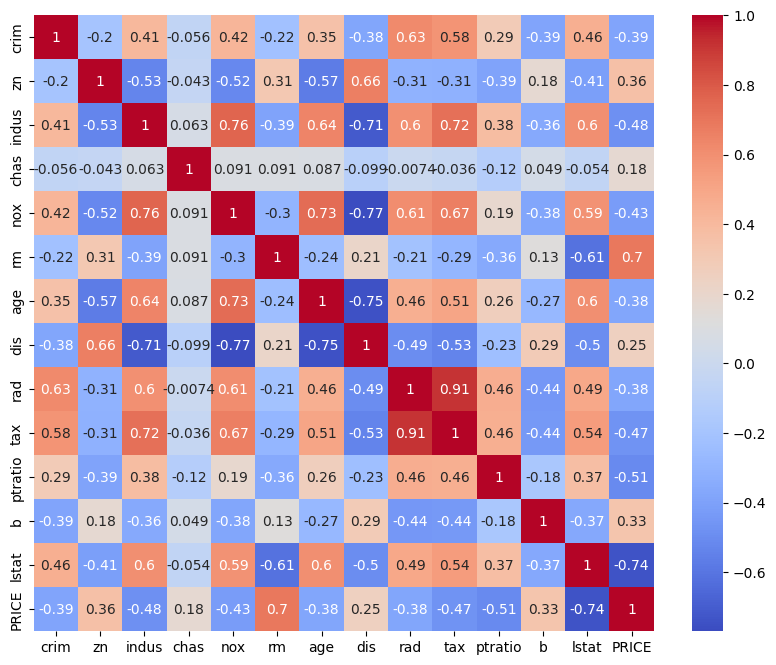

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [10]:
X = df.drop('PRICE',axis=1)
Y = df['PRICE']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = model.predict(X_test)

print('MSE: ',mean_squared_error(y_test,y_pred))
print('R2 score: ',r2_score(y_test,y_pred))

MSE:  24.29111947497374
R2 score:  0.6687594935356289


Text(0, 0.5, 'Predicted Prices')

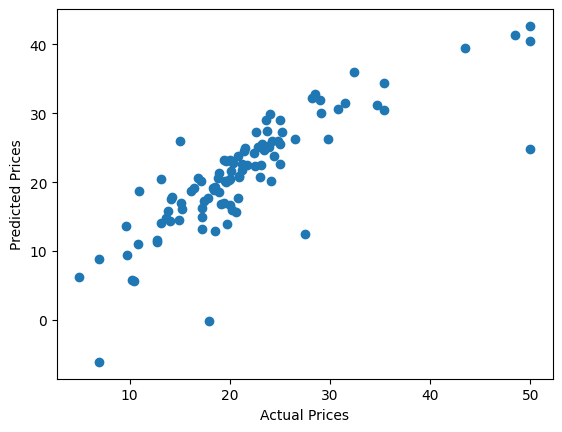

In [22]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

In [23]:
new_house = pd.DataFrame({
    'crim': [0.05],    # Very low crime rate
    'zn': [25.0],      # High proportion of residential zoning
    'indus': [4.0],    # Low industrial/business presence
    'chas': [0],       # Not on the Charles River
    'nox': [0.42],     # Low pollution (clean air)
    'rm': [7.5],       # 7.5 rooms (Large house)
    'age': [30.0],     # Relatively modern neighborhood
    'dis': [6.0],      # Further out from city employment centers
    'rad': [4],        # Good accessibility to highways
    'tax': [250.0],    # Lower property tax rate
    'ptratio': [15.2], # Good local school student-teacher ratio
    'b': [390.0],      # Demographic index (dataset baseline)
    'lstat': [5.0]     # Low percentage of lower status population
})

# Pass the new house to the trained model
prediction = model.predict(new_house)

# The output is in thousands of dollars, so we multiply by 1000 to see the real price
print(f"Predicted House Price: ${prediction[0] * 1000:,.2f}")

Predicted House Price: $35,092.71
